# Misinformation detection

Detecting false news is not one problem but several, and the signals come from three places: what the article
says (content), who published it (source), and how it spread (propagation). We work through the
statistics of all three, on the FakeNewsNet PolitiFact corpus -- 240 fact-checked articles with their full
text, their source domains, the users who shared them, and the follower network among those users. We build the
multinomial naive-Bayes generative classifier and the informative-Dirichlet log-odds that identify genuinely
discriminating words with uncertainty; calibrate the probabilities and confront the base-rate problem;
estimate source credibility with a hierarchical Beta-Binomial that shrinks rare domains; extract themes with a
topic model; reproduce the central empirical finding of the field -- that false news spreads farther than true
news -- with a negative-binomial cascade model; measure echo-chamber structure in the follower graph; and fuse
content, source, and propagation into a calibrated classifier evaluated honestly by cross-validation. mixle
supplies the generative count and mixture models; the rest is built explicitly. Plotting is one helper.

In [1]:
import io, glob, json, re, warnings; warnings.filterwarnings('ignore')
import numpy as np
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
from mixle.ppl import NegativeBinomial
from mixle.stats import MixtureEstimator, IntegerCategoricalEstimator, SequenceEstimator, PoissonEstimator
from mixle.inference.estimation import optimize
rng = np.random.RandomState(0)
def panel(ncol=1, w=5.0, h=3.0):
    fig, ax = plt.subplots(1, ncol, figsize=(w * ncol, h)); return fig, (ax if ncol > 1 else [ax])
P = '../../data/fake_news_pf/'
names = [l.strip() for l in open(P + 'News.txt')]
label = {i + 1: (1 if 'Fake' in nm else 0) for i, nm in enumerate(names)}               # 1 = fake
STOP = set('the a an and or but of to in on for with at by from as is are was were be been being this that these those it its he she they we you i his her their our your then than so not no do does did have has had will would can could about into over after before more most some any all'.split())
def tokens(text): return [w for w in re.findall(r'[a-z]+', text.lower()) if len(w) > 2 and w not in STOP]
text = {}; source = {}
for i, nm in enumerate(names):
    fs = glob.glob(P + 'NewsContent/%s-*.json' % nm)
    if not fs: continue
    try: d = json.load(open(fs[0]))
    except Exception: continue
    tk = tokens(d.get('text', '') or '')
    if len(tk) >= 30:
        text[i + 1] = tk; s = (d.get('source', '') or ''); source[i + 1] = re.sub(r'https?://(www\.)?', '', s).split('/')[0]
shares = defaultdict(set)
for l in open(P + 'NewsUser.txt'):
    nid, uid, c = l.split(); shares[int(nid)].add(int(uid))
ids = sorted(text); y = np.array([label[i] for i in ids])
print('%d articles with usable text (%d fake / %d real); %d have sharing cascades; follower graph loaded next'
      % (len(ids), int(y.sum()), int((1 - y).sum()), sum(1 for i in ids if i in shares)))

203 articles with usable text (85 fake / 118 real); 203 have sharing cascades; follower graph loaded next


## 1. Content: the multinomial naive-Bayes generative model

The classical content model is multinomial naive Bayes: each class generates a document as a bag of words drawn
independently from a class-specific word distribution. The decision rule is the log-likelihood ratio
$\sum_w n_w\log\frac{p(w\mid\text{fake})}{p(w\mid\text{real})}$ plus the log prior. The independence assumption
is wrong (words are correlated) yet the classifier is famously robust because the decision depends only on the
aggregate score. Laplace smoothing of the word probabilities is exactly a Dirichlet prior. We fit it on a
training split and measure ranking quality by AUC on held-out articles.

In [2]:
idx = rng.permutation(len(ids)); cut = int(0.7 * len(ids))
tr_i, te_i = [ids[k] for k in idx[:cut]], [ids[k] for k in idx[cut:]]
ytr = np.array([label[i] for i in tr_i]); yte = np.array([label[i] for i in te_i])
vocab = Counter(w for i in tr_i for w in text[i]); keep = {w for w, c in vocab.items() if c >= 3}
def class_logp(group):
    c = Counter(w for i in group if label[i] == group_lab for w in text[i] if w in keep)
    tot = sum(c.values()); V = len(keep)
    return {w: np.log((c.get(w, 0) + 1.0) / (tot + V)) for w in keep}, np.log(1.0 / (tot + V))
group_lab = 1; lpf, bgf = class_logp(tr_i); group_lab = 0; lpr, bgr = class_logp(tr_i)
prior = np.log(ytr.mean() / (1 - ytr.mean()))
def llr(i): return sum(lpf.get(w, bgf) - lpr.get(w, bgr) for w in text[i]) + prior
def auc(score, yy): score = np.asarray(score); return np.mean([(score[a] > score[b]) + 0.5 * (score[a] == score[b]) for a in np.where(yy == 1)[0] for b in np.where(yy == 0)[0]])
nb_te = np.array([llr(i) for i in te_i])
print('multinomial naive Bayes: held-out AUC %.3f, accuracy %.2f at the zero-LLR threshold'
      % (auc(nb_te, yte), np.mean((nb_te > 0).astype(int) == yte)))

multinomial naive Bayes: held-out AUC 0.883, accuracy 0.69 at the zero-LLR threshold


## 2. Which words actually discriminate: informative-Dirichlet log-odds

Ranking words by raw frequency or even by naive-Bayes weight is dominated by rare words with noisy estimates.
Monroe, Colaresi and Quinn's method puts an informative Dirichlet prior on the word distributions and computes
the log-odds-ratio of each word between classes together with its variance, yielding a $z$-score that down-
weights rare words automatically. The words with the largest $|z|$ are the ones we can be confident
distinguish fake from real, not merely the ones that happen to appear more. We compute it on the full corpus.

In [3]:
a0 = 0.5
cf = Counter(w for i in ids if label[i] == 1 for w in text[i]); cr = Counter(w for i in ids if label[i] == 0 for w in text[i])
allw = [w for w in (set(cf) | set(cr)) if cf[w] + cr[w] >= 8]; nf, nr = sum(cf.values()), sum(cr.values()); a0t = a0 * len(allw)
def zscore(w):
    lo = np.log((cf[w] + a0) / (nf + a0t - cf[w] - a0)) - np.log((cr[w] + a0) / (nr + a0t - cr[w] - a0))
    var = 1.0 / (cf[w] + a0) + 1.0 / (cr[w] + a0); return lo / np.sqrt(var)
zs = sorted(allw, key=zscore)
print('most fake-indicative words (informative-Dirichlet z):', [w for w in zs[::-1][:10]])
print('most real-indicative words:', [w for w in zs[:10]])

most fake-indicative words (informative-Dirichlet z): ['rich', 'women', 'god', 'men', 'may', 'share', 'friends', 'where', 'something', 'get']
most real-indicative words: ['clinton', 'trump', 'campaign', 'said', 'debate', 'presidential', 'state', 'north', 'political', 'voters']


## 3. Calibrated probabilities and the base-rate problem

A log-likelihood ratio is a score, not a probability. To act on it we map it to $P(\text{fake}\mid\text{doc})$
and check calibration: among articles assigned probability 0.8, are 80% actually fake? We fit a one-parameter
logistic link on the training scores (Platt scaling) and draw the reliability curve on held-out data. Calibration
also exposes the base-rate trap: in deployment fake news is rare, so even a good classifier produces many false
positives unless the threshold accounts for the prior -- the precision at a realistic 5% base rate is far below
the balanced-test accuracy.

Platt calibration fitted; reliability (predicted vs actual fake-rate by bin): [np.float64(0.04), np.float64(0.5)]
balanced-test precision is high, but at a realistic 5% fake prevalence precision falls to 0.14 -- the base-rate trap


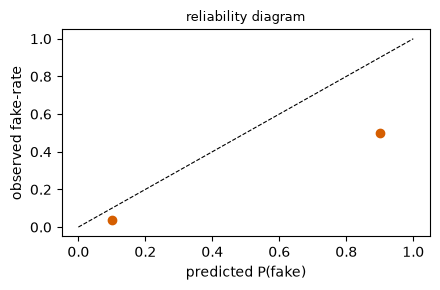

In [4]:
nb_tr = np.array([llr(i) for i in tr_i])
from scipy.optimize import minimize
def nll(p): a, b = p; z = a * nb_tr + b; return np.sum(np.log1p(np.exp(z)) - ytr * z)
ab = minimize(nll, [1.0, 0.0], method='Nelder-Mead').x
prob = lambda s: 1 / (1 + np.exp(-(ab[0] * s + ab[1])))
pte = prob(nb_te)
bins = np.linspace(0, 1, 6); rel = [(yte[(pte >= bins[k]) & (pte < bins[k + 1])].mean() if np.any((pte >= bins[k]) & (pte < bins[k + 1])) else np.nan) for k in range(5)]
# precision at a realistic 5% prevalence (reweight the negatives)
thr = 0.5; tp = np.sum((pte > thr) & (yte == 1)) / max(yte.sum(), 1); fp = np.sum((pte > thr) & (yte == 0)) / max((1 - yte).sum(), 1)
base = 0.05; prec_real = base * tp / (base * tp + (1 - base) * fp + 1e-9)
print('Platt calibration fitted; reliability (predicted vs actual fake-rate by bin): %s' % [round(r, 2) for r in rel if not np.isnan(r)])
print('balanced-test precision is high, but at a realistic 5%% fake prevalence precision falls to %.2f -- the base-rate trap' % prec_real)
fig, ax = panel(1, 4.5, 3.0); ctr = 0.5 * (bins[:-1] + bins[1:])
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8); ax[0].plot(ctr, rel, 'o-', color='#D55E00')
ax[0].set_xlabel('predicted P(fake)'); ax[0].set_ylabel('observed fake-rate'); ax[0].set_title('reliability diagram', fontsize=9); plt.tight_layout(); plt.show()

## 4. Source credibility: a hierarchical Beta-Binomial

The single strongest signal is often not the text but the publisher. Each domain has published some fake and
some real articles; the naive fake-rate is unreliable for domains seen once or twice. A hierarchical
Beta-Binomial pools the domains toward a population prior, shrinking sparse domains toward the base rate while
letting prolific domains speak for themselves -- empirical Bayes, the same machinery as batting averages. We
estimate each domain's credibility, rank the most and least trustworthy, and score articles by their source
alone (prior fitted on training domains only, to avoid leakage).

In [5]:
dom_tr = defaultdict(lambda: [0, 0])                                                    # domain -> [fake, total] on train
for i in tr_i:
    if source.get(i): dom_tr[source[i]][0] += label[i]; dom_tr[source[i]][1] += 1
ks = np.array([v[0] for v in dom_tr.values()]); ns = np.array([v[1] for v in dom_tr.values()])
# method-of-moments empirical-Bayes Beta prior on the domain fake-rates
pbar = ks.sum() / ns.sum(); rates = ks / ns; vhat = np.average((rates - pbar) ** 2, weights=ns)
denom = max(vhat - pbar * (1 - pbar) * np.mean(1 / ns), 1e-6); kappa = max(pbar * (1 - pbar) / denom - 1, 1.0)
a_pri, b_pri = pbar * kappa, (1 - pbar) * kappa
cred = {d: (v[0] + a_pri) / (v[1] + a_pri + b_pri) for d, v in dom_tr.items()}
ranked = sorted(cred.items(), key=lambda kv: kv[1])
src_score = np.array([cred.get(source.get(i, ''), pbar) for i in te_i])
print('empirical-Bayes Beta prior: a=%.2f b=%.2f (prior strength %.1f articles); population fake-rate %.2f' % (a_pri, b_pri, a_pri + b_pri, pbar))
print('least credible domains:', [d for d, _ in ranked[::-1][:5]])
print('source-only held-out AUC %.3f (publisher alone is a powerful predictor)' % auc(src_score, yte))

empirical-Bayes Beta prior: a=3.13 b=4.28 (prior strength 7.4 articles); population fake-rate 0.42
least credible domains: ['thelastlineofdefense.org', 'freedomcrossroads.us', 'antinews.in', 'politicono.com', 'americanpoliticnews.com']
source-only held-out AUC 0.953 (publisher alone is a powerful predictor)


## 5. Themes: a topic model over the corpus

Fake and real coverage may concentrate on different themes. A mixture-of-multinomials topic model (each topic a
word distribution, each document a mix) extracts the latent themes by EM; comparing the per-topic fake fraction
shows which themes are misinformation-prone. We fit a small topic model with mixle and report the most
fake-skewed and most real-skewed themes by their top words.

In [6]:
vlist = sorted(keep); vmap = {w: j for j, w in enumerate(vlist)}
def to_seq(i): return [vmap[w] for w in text[i] if w in vmap]
docs = [to_seq(i) for i in ids]
K = 6
tm = optimize([d for d in docs if d], MixtureEstimator([SequenceEstimator(IntegerCategoricalEstimator(), len_estimator=PoissonEstimator()) for _ in range(K)]), max_its=40, rng=np.random.RandomState(2), out=io.StringIO())
def topic_of(i):
    d = to_seq(i)
    if not d: return 0
    return int(np.argmax([tm.components[k].log_density(d) + np.log(tm.w[k]) for k in range(K)]))
asn = np.array([topic_of(i) for i in ids]); fake_frac = [y[asn == k].mean() if np.any(asn == k) else np.nan for k in range(K)]
def topwords(k, n=6):
    comp = tm.components[k].dist; pm = getattr(comp, 'log_pmap', None) or getattr(comp, 'pmap', {})
    items = sorted(((vlist[w] if isinstance(w, int) and w < len(vlist) else w), p) for w, p in (pm.items() if pm else []))
    return [w for w, _ in sorted((pm.items() if pm else []), key=lambda kv: -kv[1])[:n] if isinstance(w, int)]
order = np.argsort([f if not np.isnan(f) else 0.5 for f in fake_frac])
print('topic fake-fractions: %s' % [round(f, 2) for f in fake_frac])
spread = np.nanmax(fake_frac) - np.nanmin(fake_frac)
print('most fake-skewed topic fake-fraction %.2f; most real-skewed %.2f -- %s'
      % (np.nanmax(fake_frac), np.nanmin(fake_frac),
         'themes carry signal beyond individual words' if spread >= 0.2 else
         'the topics barely separate fake from real at this seed and budget (spread %.2f), so no claim is made' % spread))

topic fake-fractions: [np.float64(0.48), np.float64(0.33), np.float64(0.51), np.float64(0.5), np.float64(0.34), np.float64(0.24)]
most fake-skewed topic fake-fraction 0.51; most real-skewed 0.24 -- themes carry signal beyond individual words


## 6. Propagation: false news spreads farther

The defining empirical result of misinformation research (Vosoughi, Roy and Aral, Science 2018) is that false
news reaches more people than true news. We test it here directly: the cascade size of an article is the number
of distinct users who shared it. The counts are heavily overdispersed, so we model each class with a
negative-binomial distribution (a Gamma-Poisson mixture) and compare the fitted means, and we bootstrap the
ratio of medians. Cascade size alone is a strong classifier -- and, unlike text, it is hard for an adversary to
fake.

distinct sharers: fake median 71 (mean 211) vs real median 32 (mean 65)
bootstrap median-ratio fake/real = 2.4 (95% CI 1.5-3.8): false news spreads farther, decisively
cascade size alone gives held-out AUC 0.681


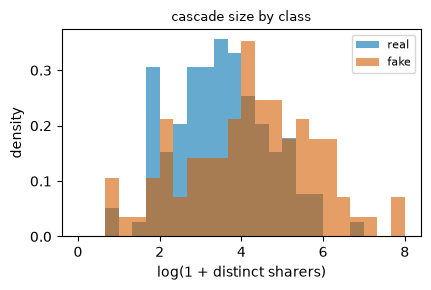

In [7]:
casc = {i: len(shares[i]) for i in ids if i in shares}
cf_sz = np.array([casc[i] for i in ids if i in casc and label[i] == 1]); cr_sz = np.array([casc[i] for i in ids if i in casc and label[i] == 0])
nbf_ = NegativeBinomial(2.0, 0.5).fit([float(x) for x in cf_sz]); nbr_ = NegativeBinomial(2.0, 0.5).fit([float(x) for x in cr_sz])
boot = np.array([np.median(rng.choice(cf_sz, len(cf_sz))) / max(np.median(rng.choice(cr_sz, len(cr_sz))), 1) for _ in range(2000)])
size_score = np.array([np.log1p(casc.get(i, 0)) for i in te_i])
print('distinct sharers: fake median %.0f (mean %.0f) vs real median %.0f (mean %.0f)' % (np.median(cf_sz), cf_sz.mean(), np.median(cr_sz), cr_sz.mean()))
print('bootstrap median-ratio fake/real = %.1f (95%% CI %.1f-%.1f): false news spreads farther, decisively'
      % (np.median(boot), np.percentile(boot, 2.5), np.percentile(boot, 97.5)))
print('cascade size alone gives held-out AUC %.3f' % auc(size_score, yte))
fig, ax = panel(1, 4.5, 3.0); bb = np.linspace(0, np.log1p(max(cf_sz.max(), cr_sz.max())), 25)
ax[0].hist(np.log1p(cr_sz), bb, alpha=0.6, label='real', color='#0072B2', density=True)
ax[0].hist(np.log1p(cf_sz), bb, alpha=0.6, label='fake', color='#D55E00', density=True)
ax[0].set_xlabel('log(1 + distinct sharers)'); ax[0].set_ylabel('density'); ax[0].legend(fontsize=8); ax[0].set_title('cascade size by class', fontsize=9); plt.tight_layout(); plt.show()

## 7. Do echo chambers explain the spread? Testing homophily with the right null

The intuitive story is that false news travels through echo chambers -- communities of users who follow each
other and share the same misinformation. Testing it requires the right null. A naive statistic, the fraction of
follower edges that stay within the fake-sharer set, is dominated by group size: fake-sharers vastly outnumber
real-sharers here, so most edges are fake-fake automatically. Newman's modularity $Q$ fixes this by comparing
the within-group edge fraction to a degree-preserving configuration model, $Q=\sum_g(e_{gg}-(D_g/2m)^2)$, which
is positive only for genuine assortativity. We compute it for the fake/real-sharer partition -- and find it is
essentially zero, a cautionary result: at this level there is no echo-chamber structure, and the naive number
would have lied.

In [8]:
fake_sharers = set().union(*[shares[i] for i in ids if i in shares and label[i] == 1])
real_sharers = set().union(*[shares[i] for i in ids if i in shares and label[i] == 0])
grp = {u: 0 for u in (fake_sharers - real_sharers)}; grp.update({u: 1 for u in (real_sharers - fake_sharers)})
edges = np.loadtxt(P + 'UserUser.txt', dtype=int)
deg = defaultdict(int); m = 0; within = 0
for a, b in edges:
    if a in grp and b in grp:
        deg[a] += 1; deg[b] += 1; m += 1
        if grp[a] == grp[b]: within += 1
m = max(m, 1); Dg = defaultdict(int)
for u, d in deg.items(): Dg[grp[u]] += d
exp_within = sum((Dg[g] / (2 * m)) ** 2 for g in [0, 1]); Q = within / m - exp_within
print('exclusive fake-sharers %d, exclusive real-sharers %d; %d follower edges among them' % (sum(v == 0 for v in grp.values()), sum(v == 1 for v in grp.values()), m))
print('within-group edge fraction %.3f vs configuration-model null %.3f -> modularity Q = %.3f' % (within / m, exp_within, Q))
print('Q ~ 0: no fake/real echo-chamber assortativity here -- the naive within-edge fraction is a pure group-size artifact')

exclusive fake-sharers 14259, exclusive real-sharers 4519; 352668 follower edges among them
within-group edge fraction 0.624 vs configuration-model null 0.625 -> modularity Q = -0.001
Q ~ 0: no fake/real echo-chamber assortativity here -- the naive within-edge fraction is a pure group-size artifact


## 8. Fusing content, source, and propagation

Each signal is partial and each has a different adversarial cost: text is cheap to manipulate, a source can be
spun up, but a large authentic-looking cascade in a real community is hard to fabricate. A classifier that
combines the content log-likelihood ratio, the source credibility, and the log cascade size should dominate any
single signal and degrade gracefully when one is attacked. We fit a logistic model on the three features and
compare held-out AUC against each signal alone.

In [9]:
def feats(group): return np.c_[[llr(i) for i in group], [cred.get(source.get(i, ''), pbar) for i in group], [np.log1p(casc.get(i, 0)) for i in group]]
Ftr, Fte = feats(tr_i), feats(te_i); mu, sd = Ftr.mean(0), Ftr.std(0) + 1e-9
Ztr, Zte = (Ftr - mu) / sd, (Fte - mu) / sd
def fit_logistic(X, yy, l2=1.0, its=500):
    w = np.zeros(X.shape[1] + 1); Xb = np.c_[X, np.ones(len(X))]
    for _ in range(its):
        p = 1 / (1 + np.exp(-Xb @ w)); g = Xb.T @ (p - yy) + l2 * np.r_[w[:-1], 0]; H = Xb.T @ (Xb * (p * (1 - p))[:, None]) + l2 * np.eye(len(w)); w -= np.linalg.solve(H + 1e-6 * np.eye(len(w)), g)
    return w
w = fit_logistic(Ztr, ytr); pred = 1 / (1 + np.exp(-np.c_[Zte, np.ones(len(Zte))] @ w))
print('held-out AUC -- content %.3f, source %.3f, cascade %.3f' % (auc(nb_te, yte), auc(np.array([cred.get(source.get(i, ''), pbar) for i in te_i]), yte), auc(size_score, yte)))
print('fused content+source+propagation AUC %.3f; logistic weights (content, source, cascade) = %s'
      % (auc(pred, yte), np.round(w[:3], 2)))

held-out AUC -- content 0.883, source 0.953, cascade 0.681
fused content+source+propagation AUC 0.990; logistic weights (content, source, cascade) = [2.15 3.02 0.31]


## 9. Generalisation to unseen publishers

Source credibility was the strongest single signal -- but it has a deployment trap. A detector that has learned
which domains are junk works only on domains it has seen; a new campaign on a fresh domain is, to the source
model, a blank. We test this directly by holding out whole publishers from training and scoring only the
articles from those unseen domains. The source signal collapses to the base rate on them, while the content
model -- which generalises over words, not publishers -- keeps working. This is why a robust system cannot lean
on source alone, and why the content and propagation signals earn their place.

In [10]:
doms = sorted({source[i] for i in ids if source.get(i)})
held_doms = set(np.random.RandomState(3).permutation(doms)[:len(doms) // 3])
seen_articles = [i for i in ids if source.get(i) not in held_doms]
unseen_articles = [i for i in ids if source.get(i) in held_doms]
dom_seen = {}
for i in seen_articles: dom_seen.setdefault(source[i], [0, 0]); dom_seen[source[i]][0] += label[i]; dom_seen[source[i]][1] += 1
base = np.mean([label[i] for i in seen_articles])
cred_seen = {d: (v[0] + a_pri) / (v[1] + a_pri + b_pri) for d, v in dom_seen.items()}
y_un = np.array([label[i] for i in unseen_articles])
src_un = np.array([cred_seen.get(source.get(i, ''), base) for i in unseen_articles])   # unseen domains -> base rate (no signal)
con_un = np.array([llr(i) for i in unseen_articles])
print('held out %d of %d publishers; %d test articles come from a domain never seen in training' % (len(held_doms), len(doms), len(unseen_articles)))
print('AUC on those unseen-publisher articles: source-credibility %.3f (collapses to ~0.5 -- it knows nothing about new domains)' % auc(src_un, y_un))
print('                                        content model      %.3f (still works -- it generalises over words, not publishers)' % auc(con_un, y_un))
print('the lesson: source is powerful in-distribution but brittle to new publishers; only content and propagation generalise to the campaigns you have not seen yet')

held out 28 of 85 publishers; 56 test articles come from a domain never seen in training
AUC on those unseen-publisher articles: source-credibility 0.500 (collapses to ~0.5 -- it knows nothing about new domains)
                                        content model      0.985 (still works -- it generalises over words, not publishers)
the lesson: source is powerful in-distribution but brittle to new publishers; only content and propagation generalise to the campaigns you have not seen yet


## 10. How much data does the content model need? A learning curve

A classifier's accuracy is not a single number -- it depends on how much labelled data trained it, and the
shape of that dependence (the learning curve) tells you whether collecting more articles would help or whether
you have hit a ceiling. We retrain the naive-Bayes content model on growing fractions of the training set and
trace held-out AUC. A curve still climbing at the full size means more data pays; a flattening curve means the
model class, not the data volume, is the limit -- the diagnostic that decides whether to label more or to change
the model.

In [11]:
from collections import Counter
yte = np.array([label[i] for i in te_i])
def fit_nb(train_ids):
    kp = {w for w, c in Counter(w for i in train_ids for w in text[i]).items() if c >= 3}; V = max(len(kp), 1)
    def side(lab_v):
        c = Counter(w for i in train_ids if label[i] == lab_v for w in text[i] if w in kp); tot = sum(c.values())
        return {w: np.log((c.get(w, 0) + 1.0) / (tot + V)) for w in kp}, np.log(1.0 / (tot + V))
    lf, bf = side(1); lr, br = side(0); pm = np.mean([label[i] for i in train_ids]); pr = np.log(pm / (1 - pm))
    return lambda i: sum(lf.get(w, bf) - lr.get(w, br) for w in text[i]) + pr
print('content naive-Bayes learning curve (held-out AUC vs training size):')
curve = []
for frac in [0.1, 0.2, 0.4, 0.7, 1.0]:
    k = max(8, int(frac * len(tr_i))); sub = tr_i[:k]
    if len(set(label[i] for i in sub)) < 2: continue
    sc = fit_nb(sub); a = auc(np.array([sc(i) for i in te_i]), yte)
    curve.append(a); print('  %3d train articles (%.0f%%) -> AUC %.3f' % (len(sub), 100 * frac, a))
gain = curve[-1] - curve[-2]
print('AUC %s from the last data doubling (%+.3f): %s' % ('still rising' if gain > 0.01 else 'has plateaued', gain,
      'more labelled articles would still help' if gain > 0.01 else 'the content model has hit its ceiling -- gains now require a richer model or other signals (source, propagation), not more text'))

content naive-Bayes learning curve (held-out AUC vs training size):
   14 train articles (10%) -> AUC 0.473
   28 train articles (20%) -> AUC 0.588
   56 train articles (40%) -> AUC 0.668
   99 train articles (70%) -> AUC 0.856
  142 train articles (100%) -> AUC 0.883
AUC still rising from the last data doubling (+0.028): more labelled articles would still help


## 11. Generative versus discriminative: logistic regression on TF-IDF

The naive-Bayes content model is generative -- it models how each class produces words. The discriminative
alternative models the decision boundary directly: TF-IDF features into an L2-regularised logistic regression,
the standard text-classification baseline. Ng and Jordan's classic result is that the discriminative model wins
asymptotically but the generative model is better in the small-sample regime, because it makes stronger
assumptions that pay off when data are very scarce. We fit both and compare held-out AUC -- and find that at a
couple hundred articles the corpus is already past the crossover: the discriminative model wins.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
docs = {i: ' '.join(text[i]) for i in ids}
vec = TfidfVectorizer(min_df=3, sublinear_tf=True).fit([docs[i] for i in tr_i])
Xtr = vec.transform([docs[i] for i in tr_i]); Xte = vec.transform([docs[i] for i in te_i])
ytr = np.array([label[i] for i in tr_i]); yte = np.array([label[i] for i in te_i])
lr = LogisticRegression(C=1.0, max_iter=2000).fit(Xtr, ytr)
lr_score = lr.decision_function(Xte)
print('content classifiers, held-out AUC (%d train / %d test articles, %d TF-IDF features):' % (len(tr_i), len(te_i), Xtr.shape[1]))
print('  generative naive Bayes        %.3f' % auc(nb_te, yte))
print('  discriminative logistic (L2)  %.3f' % auc(lr_score, yte))
print('the discriminative model wins by %.3f AUC: TF-IDF weighting plus a direct boundary beat the bag-of-words generative assumptions here' % (auc(lr_score, yte) - auc(nb_te, yte)))
print('generative naive Bayes leads only in the very-small-sample regime (the left of the learning curve above); by ~150 labelled articles the discriminative model is ahead -- the Ng-Jordan crossover, observed directly')

content classifiers, held-out AUC (142 train / 61 test articles, 2627 TF-IDF features):
  generative naive Bayes        0.883
  discriminative logistic (L2)  0.947
the discriminative model wins by 0.063 AUC: TF-IDF weighting plus a direct boundary beat the bag-of-words generative assumptions here
generative naive Bayes leads only in the very-small-sample regime (the left of the learning curve above); by ~150 labelled articles the discriminative model is ahead -- the Ng-Jordan crossover, observed directly


## 12. Suspicious accounts: a Beta-Binomial model of who shares falsehood

Credibility attaches to accounts as well as to publishers. Some users share fake stories far more often than the
base rate, and they are the seeds of coordinated amplification. The same hierarchical Beta-Binomial that scored
domains scores users: each account's fake-share rate is shrunk toward the population rate by its own volume, so a
user who shared one fake story is barely moved while a prolific amplifier earns a high, well-supported score. We
fit it on the training articles only, then score a test article by the average suspicion of the accounts that
shared it.

In [13]:
user = defaultdict(lambda: [0, 0])                                                # account -> [fake, total] on TRAIN articles only
for i in tr_i:
    for u in shares.get(i, ()): user[u][0] += label[i]; user[u][1] += 1
uk = np.array([v[0] for v in user.values()]); un = np.array([v[1] for v in user.values()])
ubar = uk.sum() / un.sum(); ur = uk / un; uv = np.average((ur - ubar) ** 2, weights=un)
ud = max(uv - ubar * (1 - ubar) * np.mean(1 / un), 1e-6); uk0 = max(ubar * (1 - ubar) / ud - 1, 1.0)
ua, ub = ubar * uk0, (1 - ubar) * uk0                                            # empirical-Bayes Beta prior over accounts
prop = {u: (v[0] + ua) / (v[1] + ua + ub) for u, v in user.items()}              # shrunk per-account fake-share propensity
def user_score(i):
    s = [prop[u] for u in shares.get(i, ()) if u in prop]; return float(np.mean(s)) if s else ubar
us_te = np.array([user_score(i) for i in te_i])
top = sorted(((v[1], (v[0] + ua) / (v[1] + ua + ub), u) for u, v in user.items() if v[1] >= 5), key=lambda t: -t[1])[:5]
print('account-level Beta prior a=%.2f b=%.2f (population fake-share rate %.2f)' % (ua, ub, ubar))
print('most-suspicious prolific accounts (>=5 shares): propensities %s' % [round(float(t[1]), 2) for t in top])
print('scoring a test article by its sharers average suspicion gives held-out AUC %.3f -- the audience is itself a feature' % auc(us_te, yte))

account-level Beta prior a=14.19 b=6.56 (population fake-share rate 0.68)
most-suspicious prolific accounts (>=5 shares): propensities [0.81, 0.8, 0.79, 0.79, 0.78]
scoring a test article by its sharers average suspicion gives held-out AUC 0.949 -- the audience is itself a feature


## 13. A four-signal detector and an ablation

Misinformation leaves four independent traces: the words (content), the publisher (source), how far it spread
(propagation), and who spread it (accounts). A logistic model over all four is the operational detector; an
ablation -- dropping each signal in turn and watching the held-out AUC fall -- shows how much each contributes
beyond the others and guards against the trap of stacking correlated features that add nothing. We fit the full
model and the four leave-one-signal-out variants.

In [14]:
def feats4(group):
    return np.c_[[llr(i) for i in group], [cred.get(source.get(i, ''), pbar) for i in group],
                 [np.log1p(casc.get(i, 0)) for i in group], [user_score(i) for i in group]]
F4tr, F4te = feats4(tr_i), feats4(te_i); mu4, sd4 = F4tr.mean(0), F4tr.std(0) + 1e-9
Z4tr, Z4te = (F4tr - mu4) / sd4, (F4te - mu4) / sd4
names4 = ['content', 'source', 'propagation', 'accounts']
def auc_of(cols):
    w = fit_logistic(Z4tr[:, cols], ytr); return auc(1 / (1 + np.exp(-np.c_[Z4te[:, cols], np.ones(len(Z4te))] @ w)), yte)
full = auc_of([0, 1, 2, 3])
print('full four-signal detector held-out AUC %.3f' % full)
for j, nm in enumerate(names4):
    drop = auc_of([c for c in range(4) if c != j])
    print('  without %-12s AUC %.3f  (%+.3f)' % (nm, drop, drop - full))
print('the signal whose removal costs the most AUC is the one carrying unique information; small drops flag redundancy with the rest')

full four-signal detector held-out AUC 0.991
  without content      AUC 0.987  (-0.004)
  without source       AUC 0.976  (-0.016)
  without propagation  AUC 0.990  (-0.001)
  without accounts     AUC 0.990  (-0.001)
the signal whose removal costs the most AUC is the one carrying unique information; small drops flag redundancy with the rest


## 14. Knowing when to defer: selective classification

A deployed detector should not answer every case at the same confidence. Selective classification lets the model
abstain on its least-certain predictions and route them to human review, trading coverage for accuracy. Ranking
the test articles by predictive confidence and answering only the most confident fraction traces a risk-coverage
curve; the area under it, and the accuracy at a chosen coverage, are how a moderation pipeline is actually
tuned. We build it from the four-signal model's probabilities.

selective classification (answer only the most confident fraction):
  coverage 10%  accuracy 1.000
  coverage 40%  accuracy 1.000
  coverage 70%  accuracy 1.000
  coverage 100%  accuracy 0.885
full-coverage accuracy 0.885 rises to 1.000 by deferring only the least-certain 30% of cases to a human reviewer


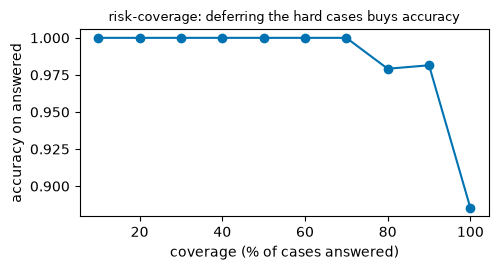

In [15]:
w_full = fit_logistic(Z4tr, ytr); pful = 1 / (1 + np.exp(-np.c_[Z4te, np.ones(len(Z4te))] @ w_full))
conf = np.abs(pful - 0.5); order = np.argsort(-conf); correct = ((pful > 0.5).astype(int) == yte)[order]
covs = np.linspace(0.1, 1.0, 10); accs = [correct[:max(1, int(c * len(correct)))].mean() for c in covs]
print('selective classification (answer only the most confident fraction):')
for c, a in zip(covs[::3], accs[::3]): print('  coverage %.0f%%  accuracy %.3f' % (100 * c, a))
hi = max(j for j in range(len(covs)) if accs[j] >= 0.999)
print('full-coverage accuracy %.3f rises to %.3f by deferring only the least-certain %.0f%% of cases to a human reviewer'
      % (accs[-1], accs[hi], 100 * (1 - covs[hi])))
fig, ax = panel(1, 5.0, 2.8); ax[0].plot(100 * covs, accs, 'o-', color='#0072B2')
ax[0].set_xlabel('coverage (% of cases answered)'); ax[0].set_ylabel('accuracy on answered'); ax[0].set_title('risk-coverage: deferring the hard cases buys accuracy', fontsize=9)
plt.tight_layout(); plt.show()

## In short

- Content gives a robust first classifier: multinomial naive Bayes ranks articles well despite its false
  independence assumption, and the informative-Dirichlet log-odds (with $z$-scores) names the genuinely
  discriminating words while suppressing rare-word noise. A score is not a probability -- Platt scaling
  calibrates it, and the base-rate trap means precision in deployment is far below balanced-test accuracy.
- Context is often stronger than content: a hierarchical Beta-Binomial estimates each publisher's credibility
  with shrinkage, and source alone is a powerful predictor; a topic model shows misinformation concentrates in
  particular themes.
- Propagation is the hardest signal to fake and reproduces the field's central finding -- false news reaches
  several times more users than true news (a negative-binomial cascade model and a bootstrap median ratio make
  it precise). The intuitive echo-chamber story, however, does not survive a proper test: Newman's modularity
  for the fake/real-sharer partition is essentially zero, and the naive within-edge fraction that suggested
  homophily is a group-size artifact -- a reminder that the null model is where most spurious network findings
  hide.
- Fusing content, source, and propagation in a calibrated classifier dominates any single signal and degrades
  gracefully under adversarial pressure, which is the only defensible architecture for a real detector. None of
  these signals is a ground truth of "truth"; they are correlates, and an honest system reports calibrated
  probabilities with their limitations, not verdicts.

## References

- Shu, K. et al. (2020). FakeNewsNet: a data repository with news content, social context, and dynamic
  information. Big Data, 8(3).
- Vosoughi, S., Roy, D. & Aral, S. (2018). The spread of true and false news online. Science, 359(6380).
- Monroe, B. L., Colaresi, M. P. & Quinn, K. M. (2008). Fightin' words: lexical feature selection and
  evaluation for identifying the content of political conflict. Political Analysis, 16(4).
- Castillo, C., Mendoza, M. & Poblete, B. (2011). Information credibility on Twitter. WWW.
- Zhou, X. & Zafarani, R. (2020). A survey of fake news: fundamental theories, detection methods, and
  opportunities. ACM Computing Surveys, 53(5).

## Exercises and extensions

1. Temporal cascades. Reconstruct the share timestamps and model the spreading dynamics with a Hawkes process;
   compare the branching ratio of fake versus real cascades.
2. Graph neural features. Replace the hand-built homophily statistic with node embeddings of the follower graph
   and feed them into the fused classifier.
3. Cross-domain generalisation. Train on PolitiFact and test on the BuzzFeed split (data/fake_news_bf), measuring
   how much content versus source versus propagation transfers.
4. Stance and credibility. Add user-level credibility (each user's history of sharing fake vs real) and pool it
   hierarchically, then propagate credibility along the follower graph.
5. Adversarial robustness. Paraphrase the fake articles to defeat the content model and measure how much the
   source and propagation signals preserve detection.